In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import RobustScaler

In [ ]:
cd C:\Users\gerai\Documents\GitHub\WHO_project
venv\Scripts\activate.bat
streamlit run app.py

In [2]:
df = pd.read_csv("Life Expectancy Data.csv")

In [3]:
df.head()

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,...,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,...,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,...,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,...,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,...,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7


# EDA

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2864 entries, 0 to 2863
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      2864 non-null   str    
 1   Region                       2864 non-null   str    
 2   Year                         2864 non-null   int64  
 3   Infant_deaths                2864 non-null   float64
 4   Under_five_deaths            2864 non-null   float64
 5   Adult_mortality              2864 non-null   float64
 6   Alcohol_consumption          2864 non-null   float64
 7   Hepatitis_B                  2864 non-null   int64  
 8   Measles                      2864 non-null   int64  
 9   BMI                          2864 non-null   float64
 10  Polio                        2864 non-null   int64  
 11  Diphtheria                   2864 non-null   int64  
 12  Incidents_HIV                2864 non-null   float64
 13  GDP_per_capita               

In [5]:
df["Country"].unique()

<ArrowStringArray>
[           'Turkiye',              'Spain',              'India',
             'Guyana',             'Israel',         'Costa Rica',
 'Russian Federation',            'Hungary',             'Jordan',
            'Moldova',
 ...
           'Suriname',          'Mauritius',           'Barbados',
        'El Salvador',       'Burkina Faso',              'Qatar',
               'Fiji',          'Australia',    'North Macedonia',
            'Georgia']
Length: 179, dtype: str

In [6]:
df["Region"].unique()

<ArrowStringArray>
[                  'Middle East',                'European Union',
                          'Asia',                 'South America',
 'Central America and Caribbean',                'Rest of Europe',
                        'Africa',                       'Oceania',
                 'North America']
Length: 9, dtype: str

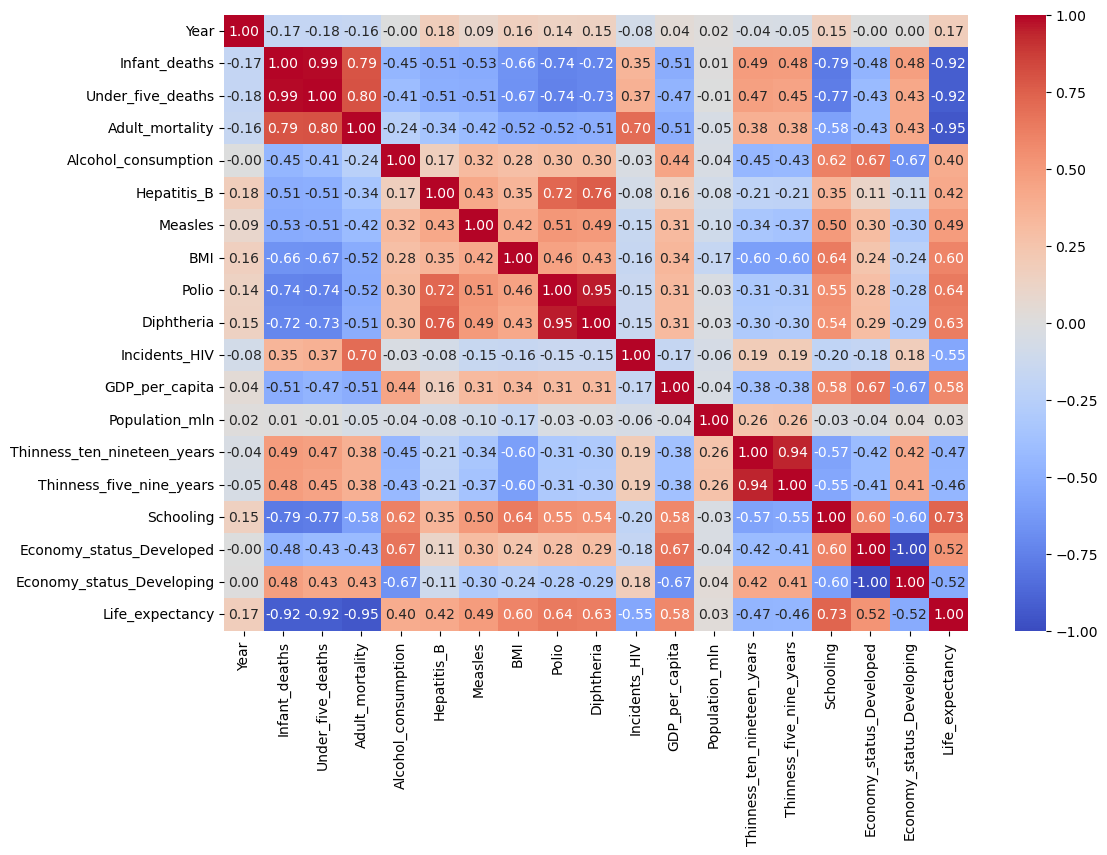

In [13]:
corr = df.corr(numeric_only=True)

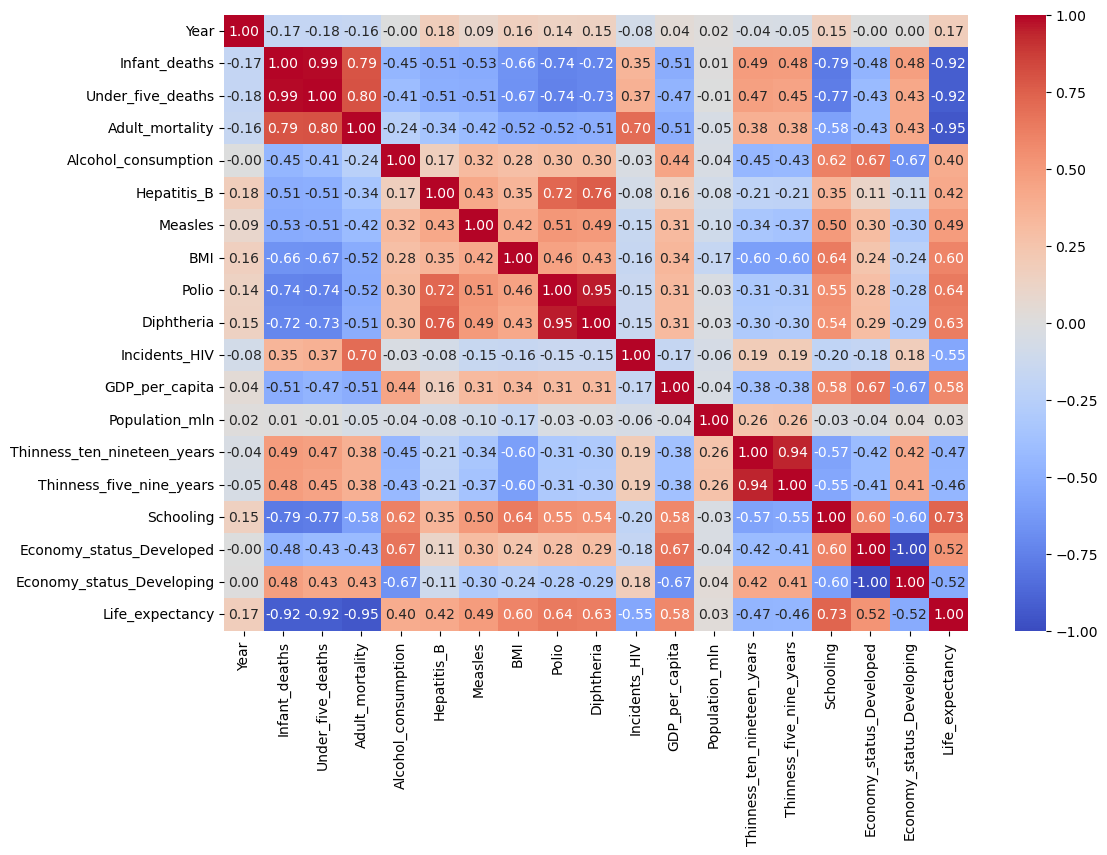

In [14]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

# Preprocessing

In [61]:
# one row per country, keeping its region
country_region = df[['Country', 'Region']].drop_duplicates()

# stratified split on Region, at country level
train_countries, test_countries = train_test_split(
    country_region,
    test_size=0.2,
    stratify=country_region['Region'],
    random_state=42
)

# expand back out to full rows for those countries
train_df = df[df['Country'].isin(train_countries['Country'])]
test_df = df[df['Country'].isin(test_countries['Country'])]

print(train_df.shape, test_df.shape)

(2288, 21) (576, 21)


In [62]:
print(train_df['Region'].value_counts(normalize=True))
print(test_df['Region'].value_counts(normalize=True))

overlap = set(train_df['Country']) & set(test_df['Country'])
print('overlap:', overlap) # should be empty set

Region
Africa                           0.286713
European Union                   0.153846
Asia                             0.146853
Central America and Caribbean    0.104895
Rest of Europe                   0.083916
Middle East                      0.076923
South America                    0.069930
Oceania                          0.062937
North America                    0.013986
Name: proportion, dtype: float64
Region
Africa                           0.277778
Asia                             0.166667
European Union                   0.138889
Central America and Caribbean    0.111111
Middle East                      0.083333
Rest of Europe                   0.083333
Oceania                          0.055556
South America                    0.055556
North America                    0.027778
Name: proportion, dtype: float64
overlap: set()


In [20]:
train_df = pd.get_dummies(train_df, columns=['Region'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Region'], drop_first=True)
print([c for c in test_df.columns if c.startswith('Region_')])

['Region_Asia', 'Region_Central America and Caribbean', 'Region_European Union', 'Region_Middle East', 'Region_North America', 'Region_Oceania', 'Region_Rest of Europe', 'Region_South America']


In [21]:
region_cols = ['Region_Asia', 'Region_Central America and Caribbean', 'Region_European Union', 'Region_Middle East', 'Region_North America', 'Region_Oceania', 'Region_Rest of Europe', 'Region_South America']

In [22]:
test_df[region_cols] = test_df[region_cols].astype(int)
train_df[region_cols] = train_df[region_cols].astype(int)

In [33]:
cols_to_scale = ['Year', 'Infant_deaths', 'Under_five_deaths',
            'Adult_mortality', 'Alcohol_consumption', 'Hepatitis_B', 'Measles',
            'BMI', 'Polio', 'Diphtheria', 'Incidents_HIV', 'GDP_per_capita',
            'Population_mln', 'Thinness_ten_nineteen_years', 'Thinness_five_nine_years',
            'Schooling', 'Economy_status_Developed']

In [34]:
train_scaled = train_df.copy()
test_scaled = test_df.copy()
scaler = RobustScaler()
train_scaled[cols_to_scale] = scaler.fit_transform(train_df[cols_to_scale])
scaler = RobustScaler()
test_scaled[cols_to_scale] = scaler.fit_transform(test_df[cols_to_scale])

In [35]:
test_scaled.head()

,Country,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,...,Economy_status_Developing,Life_expectancy,Region_Asia,Region_Central America and Caribbean,Region_European Union,Region_Middle East,Region_North America,Region_Oceania,Region_Rest of Europe,Region_South America
1,Spain,1.000000,-0.328117,-0.253247,-0.810668,0.704629,0.368421,0.389381,0.102564,0.222222,...,0,82.8,0,0,1,0,0,0,0,0
18,Japan,-0.333333,-0.325958,-0.247475,-0.743275,0.388944,-0.368421,0.035398,-0.769231,0.111111,...,0,81.9,1,0,0,0,0,0,0,0
32,South Africa,-0.200000,0.664868,0.841991,2.028921,0.298368,-0.368421,-1.061947,0.256410,-0.777778,...,1,53.8,0,0,0,0,0,0,0,0
37,Kiribati,-0.466667,0.679978,0.631313,0.162326,-0.608725,-1.210526,-1.734513,0.897436,-1.777778,...,1,64.2,0,0,0,0,0,1,0,0
41,Togo,0.066667,0.939018,1.061328,0.807216,-0.482184,-0.421053,-0.672566,-0.692308,-0.722222,...,1,56.2,0,0,0,0,0,0,0,0


In [24]:
# Column designations, 'Country' and 'Economy_status_Developing' removed from all, sensitive columns are any medical/health data
simple_cols = ['Region_Asia', 'Region_Central America and Caribbean', 'Region_European Union', 'Region_Middle East', 'Region_North America', 'Region_Oceania', 'Region_Rest of Europe', 'Region_South America',
               'Year', 'GDP_per_capita', 'Population_mln',
               'Schooling', 'Economy_status_Developed']
all_cols0 = ['Region_Asia', 'Region_Central America and Caribbean', 'Region_European Union', 'Region_Middle East', 'Region_North America', 'Region_Oceania', 'Region_Rest of Europe', 'Region_South America', 
            'Year', 'Infant_deaths', 'Under_five_deaths',
            'Adult_mortality', 'Alcohol_consumption', 'Hepatitis_B', 'Measles',
            'BMI', 'Polio', 'Diphtheria', 'Incidents_HIV', 'GDP_per_capita',
            'Population_mln', 'Thinness_ten_nineteen_years', 'Thinness_five_nine_years',
            'Schooling', 'Economy_status_Developed']
sensitive_cols0 = ['Infant_deaths', 'Under_five_deaths', 'Adult_mortality',
                   'Alcohol_consumption', 'Hepatitis_B', 'Measles', 'BMI',
                   'Polio', 'Diphtheria', 'Incidents_HIV',
                   'Thinness_ten_nineteen_years', 'Thinness_five_nine_years']

In [37]:
y_train, y_test = train_scaled['Life_expectancy'], test_scaled['Life_expectancy']
eth_train, eth_test = train_scaled[simple_cols0], test_scaled[simple_cols0]
rob_train, rob_test = train_scaled[all_cols0], test_scaled[all_cols0]

# Modelling

In [42]:
def sm_lin_reg(X_train, X_test, y_train, y_test):
    
    model = sm.OLS(y_train, X_train).fit()
    print(model.summary())

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_rmse = ((y_train - train_preds) ** 2).mean() ** 0.5
    test_rmse = ((y_test - test_preds) ** 2).mean() ** 0.5
    
    print(f"Test RMSE: {test_rmse}")
    print(f"Train RMSE: {train_rmse}")
    return

def sk_lin_reg(X_train, X_test, y_train, y_test):
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    train_rmse = ((y_train - train_preds) ** 2).mean() ** 0.5
    test_rmse = ((y_test - test_preds) ** 2).mean() ** 0.5
    
    print(f"Test RMSE: {test_rmse}")
    print(f"Train RMSE: {train_rmse}")
    print("Coefficients:")
    for col, coef in zip(X_train.columns, model.coef_):
        print(f"  {col}: {coef}")
    return model, test_rmse, train_rmse

In [43]:
sk_lin_reg(eth_train, eth_test, y_train, y_test)

Test RMSE: 4.357072017404195
Train RMSE: 4.8934114035887335
Coefficients:
  Region_Asia: 8.043593286340696
  Region_Central America and Caribbean: 11.605937768219356
  Region_European Union: 8.937386158590517
  Region_Middle East: 11.33046304598147
  Region_North America: 11.593937196922361
  Region_Oceania: 7.612896754807313
  Region_Rest of Europe: 8.984784533168186
  Region_South America: 11.013047358676097
  Year: 1.8988832933932895
  GDP_per_capita: 1.061051353244763
  Population_mln: 0.028905924525000515
  Schooling: 4.031267532552377
  Economy_status_Developed: 2.3972513878858503


(LinearRegression(),
 np.float64(4.357072017404195),
 np.float64(4.8934114035887335))

In [44]:
lin_reg(rob_train, rob_test, y_train, y_test)

                                 OLS Regression Results                                
Dep. Variable:        Life_expectancy   R-squared (uncentered):                   0.916
Model:                            OLS   Adj. R-squared (uncentered):              0.915
Method:                 Least Squares   F-statistic:                              991.1
Date:                Wed, 22 Jul 2026   Prob (F-statistic):                        0.00
Time:                        11:32:45   Log-Likelihood:                         -10120.
No. Observations:                2288   AIC:                                  2.029e+04
Df Residuals:                    2263   BIC:                                  2.043e+04
Df Model:                          25                                                  
Covariance Type:            nonrobust                                                  
                                           coef    std err          t      P>|t|      [0.025      0.975]
---------------

# Model Tuning

In [51]:
X = rob_train
vifs = []
for i in range(X.shape[1]):
    v = variance_inflation_factor(X.values, i)
    vifs.append((X.columns[i], v))

for name, v in vifs:
    print(name, round(v,2))

Region_Asia 2.01
Region_Central America and Caribbean 1.12
Region_European Union 6.26
Region_Middle East 1.46
Region_North America 1.21
Region_Oceania 1.29
Region_Rest of Europe 1.28
Region_South America 1.1
Year 1.09
Infant_deaths 8.48
Adult_mortality 8.13
Alcohol_consumption 3.57
Hepatitis_B 2.84
Measles 1.83
BMI 3.7
Diphtheria 4.67
Incidents_HIV 3.16
GDP_per_capita 3.05
Population_mln 1.31
Thinness_ten_nineteen_years 2.52
Schooling 5.17
Economy_status_Developed 9.79


In [47]:
all_cols = ['Region_Asia', 'Region_Central America and Caribbean', 'Region_European Union', 'Region_Middle East', 'Region_North America', 'Region_Oceania', 'Region_Rest of Europe', 'Region_South America', 
            'Year', 'Infant_deaths',
            'Adult_mortality', 'Alcohol_consumption', 'Hepatitis_B', 'Measles',
            'BMI', 'Diphtheria', 'Incidents_HIV', 'GDP_per_capita',
            'Population_mln', 'Thinness_ten_nineteen_years',
            'Schooling', 'Economy_status_Developed']
sensitive_cols0 = ['Under_five_deaths', 'Adult_mortality',
                   'Alcohol_consumption', 'Hepatitis_B', 'Measles', 'BMI', 'Diphtheria', 'Incidents_HIV',
                   'Thinness_ten_nineteen_years']

In [48]:
y_train, y_test = train_scaled['Life_expectancy'], test_scaled['Life_expectancy']
eth_train, eth_test = train_scaled[simple_cols], test_scaled[simple_cols]
rob_train, rob_test = train_scaled[all_cols], test_scaled[all_cols]

In [49]:
sk_lin_reg(eth_train, eth_test, y_train, y_test)

Test RMSE: 4.357072017404195
Train RMSE: 4.8934114035887335
Coefficients:
  Region_Asia: 8.043593286340696
  Region_Central America and Caribbean: 11.605937768219356
  Region_European Union: 8.937386158590517
  Region_Middle East: 11.33046304598147
  Region_North America: 11.593937196922361
  Region_Oceania: 7.612896754807313
  Region_Rest of Europe: 8.984784533168186
  Region_South America: 11.013047358676097
  Year: 1.8988832933932895
  GDP_per_capita: 1.061051353244763
  Population_mln: 0.028905924525000515
  Schooling: 4.031267532552377
  Economy_status_Developed: 2.3972513878858503


(LinearRegression(),
 np.float64(4.357072017404195),
 np.float64(4.8934114035887335))

In [50]:
sk_lin_reg(rob_train,rob_test,y_train,y_test)

Test RMSE: 3.1852345576556074
Train RMSE: 1.179979389863924
Coefficients:
  Region_Asia: 0.894632003464153
  Region_Central America and Caribbean: 2.6860755017649085
  Region_European Union: -0.41908365969043804
  Region_Middle East: 0.5417581998295311
  Region_North America: 1.5000566699431384
  Region_Oceania: -0.3509850257378764
  Region_Rest of Europe: 0.8129737428269913
  Region_South America: 2.2811984768073374
  Year: 0.33373549658181323
  Infant_deaths: -4.66176732686756
  Adult_mortality: -6.2839473929190115
  Alcohol_consumption: -0.1817059697837521
  Hepatitis_B: -0.22160884583773247
  Measles: 0.21333355579428973
  BMI: -0.4413872051885245
  Diphtheria: 0.06077098384484907
  Incidents_HIV: 0.05016369553047724
  GDP_per_capita: 0.15336303611816937
  Population_mln: -0.008427984927545928
  Thinness_ten_nineteen_years: -0.021911866327238905
  Schooling: 0.3360717028146369
  Economy_status_Developed: 2.6313227163719852


(LinearRegression(),
 np.float64(3.1852345576556074),
 np.float64(1.179979389863924))

In [55]:
models = {}
models['OLS'] = LinearRegression()
models['Ridge'] = Ridge(alpha=1.0)
models['Lasso'] = Lasso(alpha=0.1)

for name in models:
    m = models[name]
    m.fit(rob_train, y_train)
    pred = m.predict(rob_test)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)
    print(name, 'RMSE', round(rmse,3), 'R2', round(r2,3))

print()
print('Lasso coefficients:')
i = 0
while i < len(all_cols):
    print(all_cols[i], round(models['Lasso'].coef_[i], 3))
    i += 1

OLS RMSE 3.185 R2 0.9
Ridge RMSE 3.18 R2 0.9
Lasso RMSE 3.279 R2 0.894

Lasso coefficients:
Region_Asia 0.0
Region_Central America and Caribbean 0.354
Region_European Union 0.0
Region_Middle East -0.0
Region_North America 0.0
Region_Oceania -0.0
Region_Rest of Europe -0.0
Region_South America 0.0
Year 0.0
Infant_deaths -4.851
Adult_mortality -6.079
Alcohol_consumption 0.149
Hepatitis_B -0.0
Measles 0.0
BMI -0.0
Diphtheria 0.005
Incidents_HIV -0.0
GDP_per_capita 0.38
Population_mln -0.0
Thinness_ten_nineteen_years -0.0
Schooling 0.334
Economy_status_Developed 0.0


# Integrating

In [57]:
# one row per country, keeping its region
country_region = df[['Country', 'Region']].drop_duplicates()

# stratified split on Region, at country level
train_countries, test_countries = train_test_split(
    country_region,
    test_size=0.2,
    stratify=country_region['Region'],
    random_state=42
)

# expand back out to full rows for those countries
train_df = df[df['Country'].isin(train_countries['Country'])]
test_df = df[df['Country'].isin(test_countries['Country'])]

print(train_df.shape, test_df.shape)

(2288, 21) (576, 21)


In [58]:
y_train, y_test = train_scaled['Life_expectancy'], test_scaled['Life_expectancy']
eth_train, eth_test = train_scaled[simple_cols], test_scaled[simple_cols]
rob_train, rob_test = train_scaled[all_cols], test_scaled[all_cols]

## Robust

In [60]:
X_train = rob_train
X_test = rob_test

#country_train = X_train['Country']
#country_test = X_test['Country']

# TRAINING DATA PREPROCESSING
r_features = ['Year','Infant_deaths','Under_five_deaths','Adult_mortality',
              'Alcohol_consumption','Hepatitis_B','Measles','BMI','Polio',
              'Diphtheria','Incidents_HIV','GDP_per_capita','Population_mln',
              'Thinness_ten_nineteen_years','Thinness_five_nine_years',
              'Schooling','Economy_status_Developed']

# Fit scaler and encoder on TRAINING data only
r_scale = RobustScaler()
X_train_robust = pd.DataFrame(
    r_scale.fit_transform(X_train[r_features]),
    columns=r_features, 
    index=X_train.index
)

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False,drop='first')
encoder.set_output(transform="pandas")
X_train_encoded = encoder.fit_transform(X_train[['Region']])

# Combine encoded + scaled features for training
X_train_processed = pd.concat([X_train_encoded, X_train_robust], axis=1)

# TEST DATA PREPROCESSING (using fitted scaler & encoder)
X_test_robust = pd.DataFrame(
    r_scale.transform(X_test[r_features]),  # Use transform, not fit_transform for the test data
    columns=r_features,
    index=X_test.index
)

X_test_encoded = encoder.transform(X_test[['Region']])  # Already fit above

# Combine encoded + scaled features for testing
X_test_processed = pd.concat([X_test_encoded, X_test_robust], axis=1)

KeyError: "['Under_five_deaths', 'Polio', 'Thinness_five_nine_years'] not in index"

## Ethical